In [2]:
# =====================================================
# COVID-19 and World Happiness Report Data Analysis
# =====================================================
# Author: [Your Name]
# Module: 12 - COVID-19 Data Analysis Project
# =====================================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configure visual settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("deep")


Matplotlib is building the font cache; this may take a moment.


In [ ]:
# =====================================================
# 1. Load the datasets
# =====================================================
confirmed = pd.read_csv('covid19_Confirmed_dataset.csv')
deaths = pd.read_csv('covid19_deaths_dataset.csv')
happiness = pd.read_csv('worldwide_happiness_report.csv')

print("✅ Datasets loaded successfully!")


✅ Datasets loaded successfully!


In [4]:
# =====================================================
# 2. Explore datasets
# =====================================================
print("Confirmed dataset shape:", confirmed.shape)
print("Deaths dataset shape:", deaths.shape)
print("Happiness dataset shape:", happiness.shape)

display(confirmed.head(3))
display(deaths.head(3))
display(happiness.head(3))


Confirmed dataset shape: (266, 104)
Deaths dataset shape: (266, 104)
Happiness dataset shape: (156, 9)


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20
0,NaN,Afghanistan,33.0000,65.0000,0,0,0,0,0,0,...,1092,1176,1279,1351,1463,1531,1703,1828,1939,2171
1,NaN,Albania,41.1533,20.1683,0,0,0,0,0,0,...,609,634,663,678,712,726,736,750,766,773
2,NaN,Algeria,28.0339,1.6596,0,0,0,0,0,0,...,2811,2910,3007,3127,3256,3382,3517,3649,3848,4006


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20
0,NaN,Afghanistan,33.0000,65.0000,0,0,0,0,0,0,...,36,40,42,43,47,50,57,58,60,64
1,NaN,Albania,41.1533,20.1683,0,0,0,0,0,0,...,26,27,27,27,27,28,28,30,30,31
2,NaN,Algeria,28.0339,1.6596,0,0,0,0,0,0,...,392,402,407,415,419,425,432,437,444,450


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341


In [5]:
# =====================================================
# 3. Clean and preprocess COVID datasets
# =====================================================
# Drop unnecessary columns (if any)
if 'Province/State' in confirmed.columns:
    confirmed = confirmed.drop(columns=['Province/State'], errors='ignore')
if 'Province/State' in deaths.columns:
    deaths = deaths.drop(columns=['Province/State'], errors='ignore')

# Aggregate by country
confirmed_country = confirmed.groupby('Country/Region').sum()
deaths_country = deaths.groupby('Country/Region').sum()

# Remove non-date columns (like Lat/Long)
confirmed_country = confirmed_country.drop(columns=['Lat', 'Long'], errors='ignore')
deaths_country = deaths_country.drop(columns=['Lat', 'Long'], errors='ignore')

# Get total cases and deaths per country
total_cases = confirmed_country.iloc[:, -1]
total_deaths = deaths_country.iloc[:, -1]

covid_summary = pd.DataFrame({
    'Country': total_cases.index,
    'Total_Cases': total_cases.values,
    'Total_Deaths': total_deaths.values
})

covid_summary['Death_Rate_%'] = (covid_summary['Total_Deaths'] / covid_summary['Total_Cases']) * 100
covid_summary = covid_summary.replace([np.inf, -np.inf], np.nan).dropna()
covid_summary.head(10)


,Country,Total_Cases,Total_Deaths,Death_Rate_%
0,Afghanistan,2171,64,2.947950
1,Albania,773,31,4.010349
2,Algeria,4006,450,11.233150
3,Andorra,745,42,5.637584
4,Angola,27,2,7.407407
5,Antigua and Barbuda,24,3,12.500000
6,Argentina,4428,218,4.923216
7,Armenia,2066,32,1.548887
8,Australia,6766,93,1.374520
9,Austria,15452,584,3.779446


In [ ]:
# =====================================================
# 4. Prepare Happiness dataset 
# =====================================================

# Standardize column names
happiness.columns = happiness.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

# Let's check them
print("Cleaned columns:", happiness.columns.tolist())

# Select key columns that exist in your dataset
happiness_selected = happiness[['Country_or_region', 'Score', 'GDP_per_capita',
                                'Social_support', 'Healthy_life_expectancy', 
                                'Freedom_to_make_life_choices']].copy()

# Rename columns to match the COVID dataset merge convention
happiness_selected.rename(columns={
    'Country_or_region': 'Country',
    'Score': 'Happiness_Score',
    'GDP_per_capita': 'GDP_per_Capita',
    'Social_support': 'Social_Support',
    'Healthy_life_expectancy': 'Healthy_Life_Expectancy',
    'Freedom_to_make_life_choices': 'Freedom'
}, inplace=True)

# Display first rows
happiness_selected.head()


Cleaned columns: ['Overall_rank', 'Country_or_region', 'Score', 'GDP_per_capita', 'Social_support', 'Healthy_life_expectancy', 'Freedom_to_make_life_choices', 'Generosity', 'Perceptions_of_corruption']


,Country,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom
0,Finland,7.769,1.340,1.587,0.986,0.596
1,Denmark,7.600,1.383,1.573,0.996,0.592
2,Norway,7.554,1.488,1.582,1.028,0.603
3,Iceland,7.494,1.380,1.624,1.026,0.591
4,Netherlands,7.488,1.396,1.522,0.999,0.557


In [8]:
# =====================================================
# 5. Merge COVID and Happiness data
# =====================================================
merged = pd.merge(covid_summary, happiness_selected, on='Country', how='inner')

print("Merged dataset shape:", merged.shape)
merged.head()


Merged dataset shape: (143, 9)


,Country,Total_Cases,Total_Deaths,Death_Rate_%,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom
0,Afghanistan,2171,64,2.947950,3.203,0.350,0.517,0.361,0.000
1,Albania,773,31,4.010349,4.719,0.947,0.848,0.874,0.383
2,Algeria,4006,450,11.233150,5.211,1.002,1.160,0.785,0.086
3,Argentina,4428,218,4.923216,6.086,1.092,1.432,0.881,0.471
4,Armenia,2066,32,1.548887,4.559,0.850,1.055,0.815,0.283


Numeric columns used for correlation:
 ['Total_Cases', 'Total_Deaths', 'Death_Rate_%', 'Happiness_Score', 'GDP_per_Capita', 'Social_Support', 'Healthy_Life_Expectancy', 'Freedom']


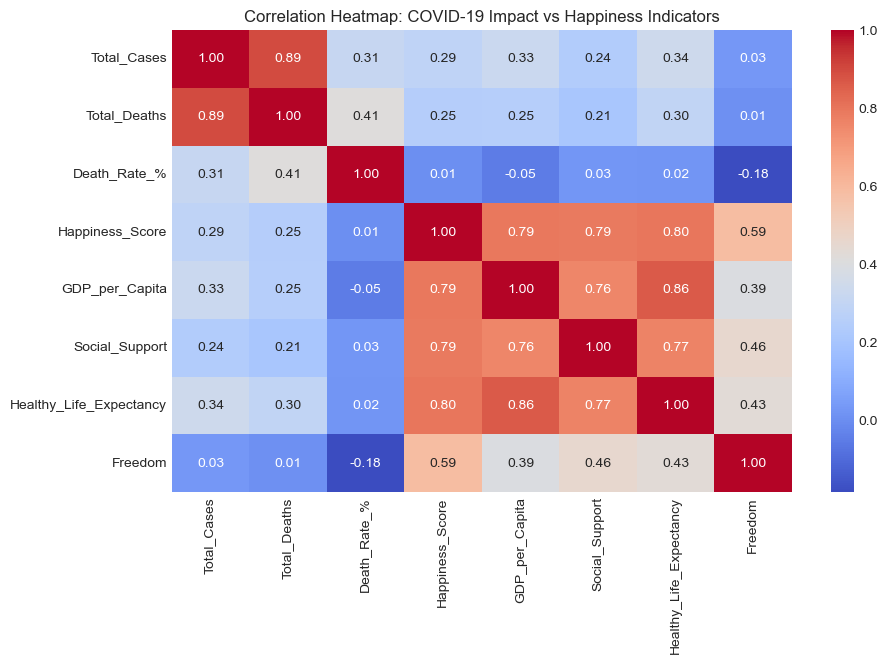

In [10]:
# =====================================================
# 6. Correlation and Insights 
# =====================================================

# Select only numeric columns for correlation
numeric_cols = merged.select_dtypes(include=['float64', 'int64'])

# Check what we’re correlating
print("Numeric columns used for correlation:\n", numeric_cols.columns.tolist())

# Generate heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap: COVID-19 Impact vs Happiness Indicators")
plt.show()


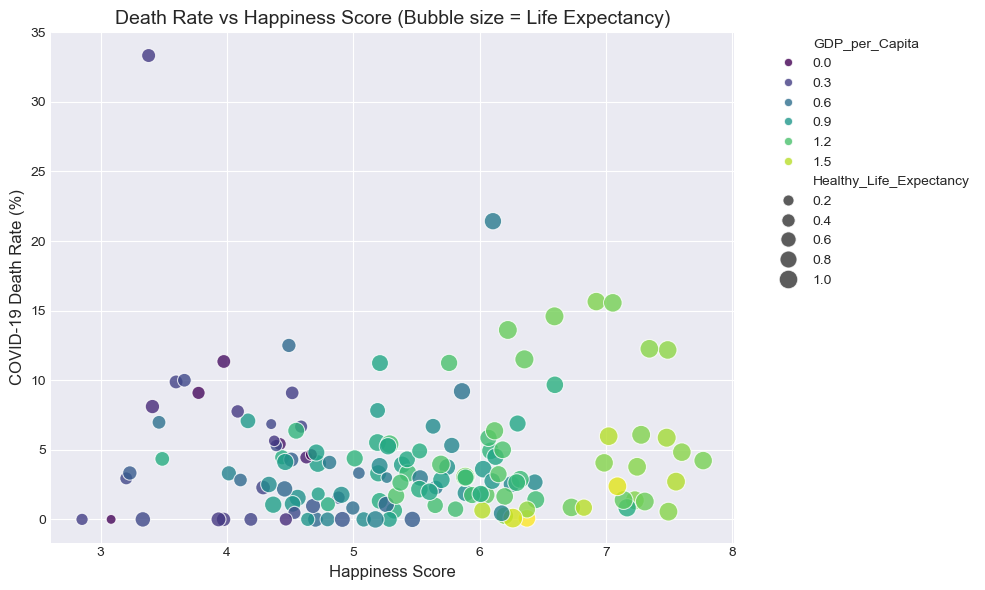

In [15]:
# =====================================================
# 7. Visualization - Death Rate vs Happiness (Final)
# =====================================================

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=merged,
    x='Happiness_Score',
    y='Death_Rate_%',
    hue='GDP_per_Capita',
    size='Healthy_Life_Expectancy',
    sizes=(50, 200),
    palette='viridis',
    alpha=0.8
)
plt.title("Death Rate vs Happiness Score (Bubble size = Life Expectancy)", fontsize=14)
plt.xlabel("Happiness Score", fontsize=12)
plt.ylabel("COVID-19 Death Rate (%)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()


In [16]:
# =====================================================
# 8. Save processed data
# =====================================================
merged.to_csv('covid19_analysis_output.csv', index=False)
print("✅ Merged dataset saved as covid19_analysis_output.csv")


✅ Merged dataset saved as covid19_analysis_output.csv
